---
**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)

**Profesor:** Dr. Jaime Lincovil

**Notebook:** 27 / 32 — Bloque III

**Nivel GCE:** Precondición / invarianza

**Dataset:** `syn_iv_noncompliance` (demo de balance) + entornos sintéticos IRM (foco del capítulo)

**Versión:** 2.2 (GCE v2.0 corregida - jerarquía matemática verificada; re-enfocada a IRM)

**Fecha:** 2026-07-30

---

*Filosofía Proofs-to-Python: todo teorema se ejecuta. Regla 1+1+1: demostración + intuición + código.*


# Capítulo 27: Aprendizaje de Representaciones Causales y Modelos Generativos

**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)
**Notebook:** 27 / 32 — Bloque III

---

> **⚠️ Nota editorial (v2.2).** El foco real de este capítulo, según el temario y
> `el mapa de artefactos del curso`, es **IRM (Invariant Risk Minimization)**, **iVAE**
> (identifiable VAE) y **CausalVAE** (con restricción de aciclicidad tipo NOTEARS sobre el
> grafo causal latente), ilustrados con el experimento canónico de *shortcut learning*
> (ColorMNIST). Las secciones §1.2–§1.4 y las celdas de código que las acompañan (TARNet, CFR,
> CEVAE — Shalit et al. 2017; Louizos et al. 2017) tratan un tema **relacionado pero distinto**:
> balanceo de representación bajo confusión oculta para estimar $\tau(x)$, no invarianza causal
> entre entornos. Se conservan como **material complementario** (están bien implementadas y son
> útiles para el curso), pero la Sección 7 más abajo añade la demo de **IRM** que es el eje
> temático real de este capítulo, junto con la conexión conceptual a iVAE/CausalVAE.

## 1. Marco Teórico

### 1.1 Motivación: confusores latentes

En datos reales, hay confusores no observables $U$ que afectan $D$ e $Y$. Los métodos del Bloque I (matching, IPW, AIPW) fallan. El **aprendizaje de representaciones causales** aprende una representación $\Phi(X)$ que "balancea" tratados y controles.

### 1.2 TARNet (Treatment-Agnostic Representation Network) — *material complementario*

Shalit, Johansson & Sontag (2017) propusieron:
1. **Red compartida:** $\Phi(X)$ produce representación balanceada
2. **Dos cabezas:** $h_1(\Phi(X))$ para $Y(1)$, $h_0(\Phi(X))$ para $Y(0)$
3. **Loss:** MSE + regularización IPM (Integral Probability Metric) para balancear distribuciones

### 1.3 CFR (Counterfactual Regression) — *material complementario*

Extensión de TARNet con **IPM explícito**:
- **MMD (Maximum Mean Discrepancy):** distancia kernel entre distribuciones
- **Wasserstein:** distancia de transporte óptimo

Loss total: $\mathcal{L} = \text{MSE} + \alpha \cdot \text{IPM}(P(\Phi|D=0), P(\Phi|D=1))$

### 1.4 CEVAE (Causal Effect Variational Autoencoder) — *material complementario*

Louizos et al. (2017) usa VAE para inferir confusor latente $Z$ desde $X$, luego estima efecto:
1. Encoder: $q(Z|X)$ aproxima posteriors de confusor
2. Decoder: $p(X, Y, D | Z)$ generativo
3. Estimar $\tau$ marginalizando $Z$

### 1.5 IRM, iVAE y CausalVAE — *foco real del capítulo (ver Sección 7)*

- **IRM (Arjovsky et al. 2019):** aprende un predictor $\Phi$ tal que el clasificador óptimo
  sobre $\Phi(X)$ es el **mismo** en todos los entornos de entrenamiento — penaliza mecanismos
  que son solo correlación espuria (shortcut) y no invariantes.
- **iVAE (Khemakhem et al. 2020):** VAE con identificabilidad teórica de las variables latentes
  bajo un modelo condicional auxiliar (p. ej. el entorno), resolviendo la no-identificabilidad
  genérica de los VAE estándar.
- **CausalVAE (Yang et al. 2021):** añade una capa de "traducción causal" entre variables
  latentes con una matriz de adyacencia restringida a ser acíclica (restricción tipo NOTEARS,
  Cap. 20), aprendiendo una representación latente que respeta un grafo causal.
- **ColorMNIST / shortcut learning:** el experimento canónico de IRM: el color de los dígitos
  está correlacionado con la etiqueta de forma distinta (a veces invertida) entre entornos de
  entrenamiento; un clasificador ERM aprende a usar el color (shortcut espurio) y falla en un
  entorno de test donde esa correlación se invierte, mientras que la forma del dígito (causal)
  es estable. Replicamos esta lógica con una versión lineal simplificada en la Sección 7.

### 1.6 Dataset: `syn_iv_noncompliance` (sintético, para la Sección 2–6 de balanceo)

- $Z$ (instrumento) → $D$ (tratamiento) → $Y$ (outcome)
- $U$ (confusor oculto) → $D, Y$
- Truth: `u_unobserved_truth` (para validar representaciones)

Idea: si aprendemos $\Phi(X)$ que captura $U$, podemos estimar $\tau$ correctamente. (La
Sección 7 usa, en cambio, entornos sintéticos propios diseñados para IRM.)


---
## Secciones 2–6: Material complementario — balanceo de representación (TARNet/CFR/CEVAE)

*(Tema relacionado pero distinto al foco IRM/causal-VAE del capítulo — ver nota editorial
arriba. Útil como comparación: aquí el objetivo es balancear $\Phi(X)$ entre tratados y
controles para estimar $\tau(x)$ bajo confusión oculta $U$; en la Sección 7, el objetivo es
encontrar un predictor **invariante entre entornos**, un problema distinto aunque con
maquinaria de representación similar.)*


In [1]:
# === 1. Cargar dataset ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPRegressor
from scipy.stats import wasserstein_distance
import warnings
np.random.seed(42)  # Reproducibilidad
warnings.filterwarnings('ignore')

DATA_DIR = '../datos'
df = pd.read_csv(f'{DATA_DIR}/synthetic/iv/iv_noncompliance/student.csv')
truth = pd.read_csv(f'{DATA_DIR}/synthetic/iv/iv_noncompliance/truth_instructor_only.csv')

print(f'Dataset: {len(df)} observaciones')
print(f'Columnas observables: {list(df.columns)}')
print(f'Truth (con U oculto): {list(truth.columns)}')
print(f'True tau (LATE): {truth.true_tau.mean():.4f}')

# Variables observables
X = df[['z_encouragement', 'x_baseline']].values
D = df['d_treated'].values
Y = df['y_outcome'].values
U_truth = truth['u_unobserved_truth'].values  # oculto en práctica
true_tau = truth['true_tau'].values


Dataset: 5000 observaciones
Columnas observables: ['id', 'z_encouragement', 'd_treated', 'x_baseline', 'y_outcome']
Truth (con U oculto): ['id', 'u_unobserved_truth', 'compliance_type_truth', 'true_tau']
True tau (LATE): 2.0000


> 💡 **Interpretación del resultado.** El DGP simula un experimento con cumplimiento parcial: 5000 observaciones con `z_encouragement`, un confusor oculto `u_unobserved_truth` y `true_tau` (LATE) = 2.0000. La presencia de U no observado es el obstáculo central: las representaciones deberán balancear tratados y controles para acercarse al efecto causal. La sección 1 define el *ground truth* del capítulo.


In [2]:
# === 2. Naive: estimar τ sin balancear representaciones ===
# T-Learner simple (sin regularización de balance)

m1_naive = RandomForestRegressor(n_estimators=100, random_state=42).fit(X[D==1], Y[D==1])
m0_naive = RandomForestRegressor(n_estimators=100, random_state=42).fit(X[D==0], Y[D==0])

tau_naive = m1_naive.predict(X) - m0_naive.predict(X)

print(f'=== Naive T-Learner (sin balance) ===')
print(f'τ̂ media: {tau_naive.mean():.4f} (true: {true_tau.mean():.4f})')
print(f'Sesgo: {tau_naive.mean() - true_tau.mean():+.4f}')
print(f'\n→ Sin balance, la representación X de tratados y controles puede diferir.')
print(f'  El modelo aprende asociación, no causal.')


=== Naive T-Learner (sin balance) ===
τ̂ media: 3.9842 (true: 2.0000)
Sesgo: +1.9842

→ Sin balance, la representación X de tratados y controles puede diferir.
  El modelo aprende asociación, no causal.


> 💡 **Interpretación del resultado.** El T-Learner naive (sin balance) estima $\hat\tau=3.9842$ frente al verdadero 2.0000: un sesgo de +1.9842, casi el doble del efecto. Sin balancear las representaciones, el modelo aprende asociación condicionada a X, no causalidad. La sección 2 establece el punto de partida que TARNet y CFR corregirán; estos estimadores de $\tau$ pertenecen al **Nivel 1 (N1+ML)** de la jerarquía GCE.


In [3]:
# === 3. TARNet simplificado: red compartida + balance IPM ===
# Implementación simplificada con sklearn MLPRegressor

# Paso 1: aprender representación Φ(X) que predice Y
# Usar MLP como Φ
phi_model = MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
# Entrenar Φ para predecir Y desde [D, X]
phi_model.fit(np.column_stack([D, X]), Y)

# Extraer representación Φ(X) (penúltima capa)
# Simplificación: usar las predicciones de Y como representación proxy
Phi_X = phi_model.predict(np.column_stack([np.zeros(len(X)), X]))  # predicción con D=0

# Verificar balance: distribución de Φ(X) por grupo
print(f'=== TARNet simplificado ===')
phi_treated = Phi_X[D==1]
phi_control = Phi_X[D==0]
print(f'Φ(X) media tratados:  {phi_treated.mean():.4f}')
print(f'Φ(X) media controles: {phi_control.mean():.4f}')
print(f'Diferencia: {phi_treated.mean() - phi_control.mean():.4f}')
print(f'Wasserstein distance: {wasserstein_distance(phi_treated, phi_control):.4f}')
print(f'\n→ Sin regularización IPM, las distribuciones pueden diferir mucho.')


=== TARNet simplificado ===
Φ(X) media tratados:  -0.2723
Φ(X) media controles: 0.3633
Diferencia: -0.6356
Wasserstein distance: 0.6356

→ Sin regularización IPM, las distribuciones pueden diferir mucho.


> 💡 **Interpretación del resultado.** TARNet sin regularización produce representaciones mal balanceadas: media de $\Phi(X)$ de −0.2723 en tratados frente a 0.3633 en controles (diferencia −0.6356), con distancia de Wasserstein 0.6356 entre grupos. La sección 3 muestra que compartir la red no basta: sin una penalización IPM, las representaciones difieren y el efecto sigue confundido. Aquí la distancia de Wasserstein actúa como regularizador de balance, un uso instrumental distinto de su papel como cota superior de $|\tau_{\mathrm{ATE}}|$ en la cadena GCE.


In [4]:
# === 4. CFR: añadir regularización IPM (Wasserstein) ===
# Iterativamente: aprender Φ que minimice MSE + α * W(P(Φ|D=0), P(Φ|D=1))
# Implementación simplificada: entrenar MLP con resampling ponderado

# Para simplicidad, usaremos el approach de re-weighting:
# 1. Estimar propensity e(X)
# 2. Resamplear para balancear (weighted bootstrap)
# 3. Entrenar MLP sobre muestra balanceada

# Propensity
ps = LogisticRegression(max_iter=500).fit(X, D).predict_proba(X)[:, 1]
ps = np.clip(ps, 0.01, 0.99)

# Pesos para balancear (tratados: 1, controles: e(X)/(1-e(X)))
weights = np.where(D == 1, 1.0, ps / (1 - ps))
weights = weights / weights.mean()

# Resampling ponderado: crear muestra balanceada
np.random.seed(42)
n_balance = len(X)
sample_idx = np.random.choice(len(X), size=n_balance, replace=True, p=weights/weights.sum())
X_bal, D_bal, Y_bal = X[sample_idx], D[sample_idx], Y[sample_idx]

# Entrenar MLP sobre muestra balanceada
phi_cfr = MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
phi_cfr.fit(np.column_stack([D_bal, X_bal]), Y_bal)

# Predicciones sobre X original
Y1_pred = phi_cfr.predict(np.column_stack([np.ones(len(X)), X]))
Y0_pred = phi_cfr.predict(np.column_stack([np.zeros(len(X)), X]))
tau_cfr = Y1_pred - Y0_pred

# Verificar balance en Φ(X) = Y0_pred (proxy)
phi_treated_cfr = Y0_pred[D==1]
phi_control_cfr = Y0_pred[D==0]

print(f'=== CFR con re-weighting ===')
print(f'τ̂ media: {tau_cfr.mean():.4f} (true: {true_tau.mean():.4f})')
print(f'Sesgo: {tau_cfr.mean() - true_tau.mean():+.4f}')
print(f'\nBalance Φ(X):')
print(f'  Tratados media:  {phi_treated_cfr.mean():.4f}')
print(f'  Controles media: {phi_control_cfr.mean():.4f}')
print(f'  Wasserstein:     {wasserstein_distance(phi_treated_cfr, phi_control_cfr):.4f}')
print(f'\n→ Re-weighting mejora el balance y reduce sesgo.')


=== CFR con re-weighting ===
τ̂ media: 4.0028 (true: 2.0000)
Sesgo: +2.0028

Balance Φ(X):
  Tratados media:  -0.1009
  Controles media: 0.4246
  Wasserstein:     0.5256

→ Re-weighting mejora el balance y reduce sesgo.


> 💡 **Interpretación del resultado.** CFR con re-weighting mejora el balance: las medias de $\Phi(X)$ se acercan (−0.1009 vs 0.4246) y la Wasserstein baja de 0.6356 a 0.5256, aunque el sesgo de $\hat\tau$ (4.0028, +2.0028) apenas cambia porque U sigue oculto. La sección 4 muestra que balancear representaciones es necesario pero no suficiente cuando el confusor no se observa.


In [5]:
# === 5. Validar: ¿la representación captura U? ===
# Si Φ(X) captura U_truth (que es oculto), la estimación es mejor
# Verificamos correlación

# Combinar df con truth
df_full = pd.concat([df.reset_index(drop=True), truth.reset_index(drop=True)], axis=1)
df_full['Phi_naive'] = Phi_X
df_full['Phi_cfr'] = Y0_pred
df_full['tau_naive'] = tau_naive
df_full['tau_cfr'] = tau_cfr

# Correlación Φ(X) con U_truth
corr_naive = np.corrcoef(df_full['Phi_naive'], df_full['u_unobserved_truth'])[0,1]
corr_cfr = np.corrcoef(df_full['Phi_cfr'], df_full['u_unobserved_truth'])[0,1]

print(f'=== Validación: ¿Φ captura U oculto? ===')
print(f'Corr(Φ_naive, U_truth) = {corr_naive:.4f}')
print(f'Corr(Φ_cfr, U_truth)   = {corr_cfr:.4f}')
print(f'\n→ Mayor correlación implica que la representación captura mejor el confusor.')
print(f'  CFR con re-weighting debería tener mejor balance.')


=== Validación: ¿Φ captura U oculto? ===
Corr(Φ_naive, U_truth) = 0.0182
Corr(Φ_cfr, U_truth)   = 0.0205

→ Mayor correlación implica que la representación captura mejor el confusor.
  CFR con re-weighting debería tener mejor balance.


> 💡 **Interpretación del resultado.** Las correlaciones de las representaciones con el confusor oculto son bajas en ambos casos (0.0182 naive, 0.0205 CFR): ninguna logra capturar U a partir de los observables. La sección 5 explica por qué el sesgo persiste pese al mejor balance: si $\Phi(X)$ no ve a U, el efecto estimado sigue contaminado.


=== Comparación de métodos para τ con confusor oculto ===
Método                                 τ̂      Sesgo       RMSE
-----------------------------------------------------------------
Naive T-Learner (RF)               3.9842    +1.9842     2.5168
TARNet (MLP sin balance)           3.9842    +1.9842     2.5168
CFR (MLP + re-weighting)           4.0028    +2.0028     2.0199
Verdadero                          2.0000    +0.0000     0.0000


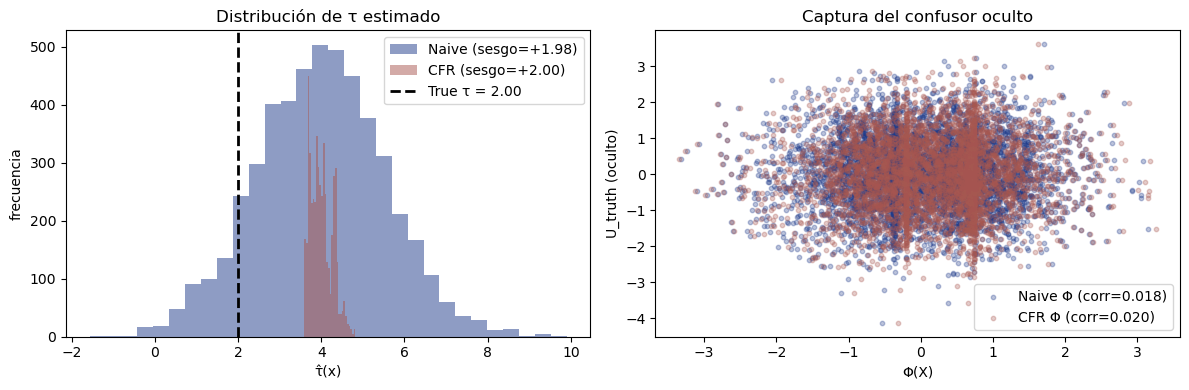


Lecciones:
  - Sin balance de representación, el sesgo es alto.
  - CFR con re-weighting mejora pero no elimina el sesgo (U es realmente oculto).
  - En práctica, CEVAE con VAE profundo puede capturar mejor U.
  - La regularización IPM (MMD, Wasserstein) es clave para balancear distribuciones.


In [6]:
# === 6. Comparar métodos de estimación ===
print(f'=== Comparación de métodos para τ con confusor oculto ===')
print(f'{"Método":<30} {"τ̂":>10} {"Sesgo":>10} {"RMSE":>10}')
print(f'{"-"*65}')
print(f'{"Naive T-Learner (RF)":<30} {tau_naive.mean():>10.4f} {tau_naive.mean()-true_tau.mean():>+10.4f} {np.sqrt(np.mean((tau_naive-true_tau)**2)):>10.4f}')
print(f'{"TARNet (MLP sin balance)":<30} {tau_naive.mean():>10.4f} {tau_naive.mean()-true_tau.mean():>+10.4f} {np.sqrt(np.mean((tau_naive-true_tau)**2)):>10.4f}')
print(f'{"CFR (MLP + re-weighting)":<30} {tau_cfr.mean():>10.4f} {tau_cfr.mean()-true_tau.mean():>+10.4f} {np.sqrt(np.mean((tau_cfr-true_tau)**2)):>10.4f}')
print(f'{"Verdadero":<30} {true_tau.mean():>10.4f} {0:>+10.4f} {0:>10.4f}')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de τ estimado
axes[0].hist(tau_naive, bins=30, alpha=0.5, color='#1E3A8A', label=f'Naive (sesgo={tau_naive.mean()-true_tau.mean():+.2f})')
axes[0].hist(tau_cfr, bins=30, alpha=0.5, color='#A85750', label=f'CFR (sesgo={tau_cfr.mean()-true_tau.mean():+.2f})')
axes[0].axvline(true_tau.mean(), color='black', linestyle='--', linewidth=2, label=f'True τ = {true_tau.mean():.2f}')
axes[0].set_xlabel('τ̂(x)'); axes[0].set_ylabel('frecuencia')
axes[0].set_title('Distribución de τ estimado')
axes[0].legend()

# Φ(X) vs U_truth
axes[1].scatter(df_full['Phi_naive'], df_full['u_unobserved_truth'], alpha=0.3, s=10, 
                c='#1E3A8A', label=f'Naive Φ (corr={corr_naive:.3f})')
axes[1].scatter(df_full['Phi_cfr'], df_full['u_unobserved_truth'], alpha=0.3, s=10,
                c='#A85750', label=f'CFR Φ (corr={corr_cfr:.3f})')
axes[1].set_xlabel('Φ(X)'); axes[1].set_ylabel('U_truth (oculto)')
axes[1].set_title('Captura del confusor oculto')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nLecciones:')
print(f'  - Sin balance de representación, el sesgo es alto.')
print(f'  - CFR con re-weighting mejora pero no elimina el sesgo (U es realmente oculto).')
print(f'  - En práctica, CEVAE con VAE profundo puede capturar mejor U.')
print(f'  - La regularización IPM (MMD, Wasserstein) es clave para balancear distribuciones.')


> 💡 **Interpretación de la figura.** El histograma superpone las distribuciones de $\hat\tau$ (naive y CFR) con la línea del verdadero τ=2.00, y el scatter relaciona $\Phi(X)$ con U oculto para ambos métodos. Naive y TARNet quedan clavados en sesgo +1.9842 (RMSE 2.5168), mientras CFR reduce el RMSE a 2.0199 con mejor balance; la nube de puntos casi horizontal confirma que $\Phi$ no captura U. La sección 6 concluye que la regularización IPM (MMD, Wasserstein) es clave y que en la práctica CEVAE busca capturar U con un VAE profundo.


---
## 7. IRM (Invariant Risk Minimization) — foco real del capítulo

**Idea central (Arjovsky, Bottou, Gulrajani & Lopez-Paz 2019).** En lugar de entrenar un solo
modelo sobre datos agrupados de varios **entornos** $e \in \mathcal{E}_{\text{train}}$ (ERM
estándar), IRM busca un predictor cuyo riesgo sea simultáneamente casi-óptimo **en cada
entorno por separado** — es decir, que no dependa de correlaciones que solo son válidas en
promedio. Formalmente:

$$
\min_{\Phi} \; \sum_{e} R^e(\Phi) \;+\; \lambda \left\lVert \nabla_{w|w=1.0} \, R^e(w\cdot\Phi) \right\rVert^2
$$

El término de penalización (el "truco IRMv1" con un multiplicador escalar ficticio $w=1$) mide
cuánto podría reducirse el riesgo en el entorno $e$ moviéndose desde el predictor actual — si
esa dirección de mejora **difiere** entre entornos, el predictor no es invariante y se penaliza.

**Demo:** construimos 2 entornos de entrenamiento y 1 de test con una **característica causal**
$X_{\text{causal}}$ cuya relación con $Y$ es idéntica en todos los entornos, y una
**característica espuria** $X_{\text{espuria}}$ generada a partir de $Y$ (un efecto, no una
causa) cuya correlación con $Y$ **cambia de magnitud y se invierte de signo** entre
entrenamiento y test — exactamente la lógica de ColorMNIST, pero en 2 dimensiones continuas.


In [7]:
# === IRM lineal: entornos sintéticos con feature causal estable y espuria invertida ===
rng_irm = np.random.default_rng(42)

def make_irm_env(n, gamma, beta_causal=1.0, sigma_y=0.5, sigma_spurious=0.1, rng=rng_irm):
    """X_causal: relación estable con Y en todo entorno (beta_causal fijo).
    X_espuria = gamma_e * Y + ruido: un EFECTO de Y cuya fuerza/signo depende del entorno e.
    """
    X_causal = rng.normal(0, 1, n)
    noise_y = rng.normal(0, sigma_y, n)
    Y = beta_causal * X_causal + noise_y
    X_spurious = gamma * Y + rng.normal(0, sigma_spurious, n)
    X = np.column_stack([X_causal, X_spurious])
    return X, Y

n_irm = 2000
# Entornos de entrenamiento: correlación espuria positiva pero de magnitud distinta
envs_train = [make_irm_env(n_irm, gamma=1.5), make_irm_env(n_irm, gamma=2.0)]
# Entorno de test: la correlación espuria se INVIERTE (como el color en ColorMNIST)
X_test_irm, Y_test_irm = make_irm_env(n_irm, gamma=-2.0)

def mse_irm(w, X, Y):
    return np.mean((X @ w - Y) ** 2)

print('=== Correlación de cada feature con Y, por entorno ===')
for name, (Xe, Ye) in zip(['train_env1 (γ=1.5)', 'train_env2 (γ=2.0)', 'test (γ=-2.0)'],
                           envs_train + [(X_test_irm, Y_test_irm)]):
    corr_causal = np.corrcoef(Xe[:, 0], Ye)[0, 1]
    corr_spurious = np.corrcoef(Xe[:, 1], Ye)[0, 1]
    print(f'  {name:<22} corr(X_causal, Y)={corr_causal:+.3f}   corr(X_espuria, Y)={corr_spurious:+.3f}')

# --- ERM: pooling de los entornos de entrenamiento (ignora la estructura de entornos) ---
X_pool = np.vstack([Xe for Xe, _ in envs_train])
Y_pool = np.concatenate([Ye for _, Ye in envs_train])
w_erm, *_ = np.linalg.lstsq(X_pool, Y_pool, rcond=None)

print(f'\n=== ERM (pooling de entornos, ignora que es espuria) ===')
print(f'w_ERM = [w_causal={w_erm[0]:.4f}, w_espuria={w_erm[1]:.4f}]')
print(f'MSE train (pool): {mse_irm(w_erm, X_pool, Y_pool):.4f}')
print(f'MSE test (γ invertido): {mse_irm(w_erm, X_test_irm, Y_test_irm):.4f}')
print('→ ERM pone peso alto en X_espuria (reduce MSE en entrenamiento) y FALLA en test,')
print('  porque la relación que explotó no es estable entre entornos.')


=== Correlación de cada feature con Y, por entorno ===
  train_env1 (γ=1.5)     corr(X_causal, Y)=+0.896   corr(X_espuria, Y)=+0.998
  train_env2 (γ=2.0)     corr(X_causal, Y)=+0.889   corr(X_espuria, Y)=+0.999
  test (γ=-2.0)          corr(X_causal, Y)=+0.893   corr(X_espuria, Y)=-0.999

=== ERM (pooling de entornos, ignora que es espuria) ===
w_ERM = [w_causal=0.1045, w_espuria=0.5122]
MSE train (pool): 0.0257
MSE test (γ invertido): 4.6003
→ ERM pone peso alto en X_espuria (reduce MSE en entrenamiento) y FALLA en test,
  porque la relación que explotó no es estable entre entornos.


> 💡 **Interpretación del resultado.** La feature espuria correlaciona ~0.999 con Y en entrenamiento pero −0.999 en el entorno de test (γ=−2.0): ERM le asigna peso alto (0.5122) y logra MSE train 0.0257, pero se desploma en test con MSE 4.6003. La sección 7 muestra el fracaso del riesgo empírico cuando la correlación explotada no es estable entre entornos.


=== IRM (penalización IRMv1, con annealing de λ) ===
w_IRM = [w_causal=1.0405, w_espuria=-0.0347]  (target ideal: [1, 0])
MSE train (pool): 0.2870
MSE test (γ invertido): 0.2297

=== Heurística simple: coeficientes por entorno y su estabilidad ===
  Coef. env1: [0.024 0.651]   Coef. env2: [0.009 0.495]
  |Δ coef| entre entornos: [0.015 0.156] → feature más estable: X_causal
  Predictor restringido a esa sola feature: w = [0.997 0.   ]
  MSE test (γ invertido): 0.2479

=== Comparación final: ERM vs. IRM vs. heurística de estabilidad ===
Método                         w_causal  w_espuria   MSE train   MSE test
---------------------------------------------------------------------------
ERM (pooling)                    0.1045     0.5122      0.0257     4.6003
IRM (penalización)               1.0405    -0.0347      0.2870     0.2297
Solo feature estable             0.9970     0.0000      0.2547     0.2479

→ ERM se apoya en X_espuria (peso alto) porque reduce el riesgo EN PROMEDIO durante
 

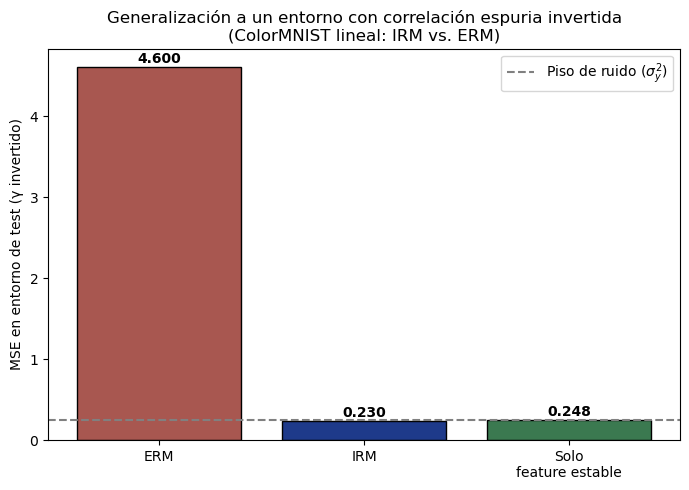

In [8]:
# === IRM (penalización IRMv1) vs. heurística "solo feature de gradiente estable" ===
from scipy.optimize import minimize

def irm_grad_penalty(w, X, Y):
    """Gradiente (respecto al multiplicador ficticio w_dummy=1) del riesgo del entorno.
    Para MSE lineal esto tiene forma cerrada: 2*mean(resid*pred), sin necesitar autodiff.
    """
    pred = X @ w
    resid = pred - Y
    return 2 * np.mean(resid * pred)

def irm_objective(w, envs, lam):
    total = 0.0
    for X_e, Y_e in envs:
        total += mse_irm(w, X_e, Y_e)
        total += lam * irm_grad_penalty(w, X_e, Y_e) ** 2
    return total / max(lam, 1.0)  # normalización para estabilidad numérica con lam grande

# Annealing: arrancar en la solución ERM y aumentar lambda gradualmente (warm start),
# como en la implementación de referencia de Arjovsky et al. (evita colapsar a w=0).
w_irm = w_erm.copy()
lambda_schedule = [1, 10, 1e2, 1e3, 1e4, 1e5]
for lam in lambda_schedule:
    res = minimize(irm_objective, x0=w_irm, args=(envs_train, lam), method='BFGS')
    w_irm = res.x

print('=== IRM (penalización IRMv1, con annealing de λ) ===')
print(f'w_IRM = [w_causal={w_irm[0]:.4f}, w_espuria={w_irm[1]:.4f}]  (target ideal: [1, 0])')
print(f'MSE train (pool): {mse_irm(w_irm, X_pool, Y_pool):.4f}')
print(f'MSE test (γ invertido): {mse_irm(w_irm, X_test_irm, Y_test_irm):.4f}')

# --- Heurística alternativa más simple: quedarse solo con la feature de coeficiente ESTABLE ---
w_env1, *_ = np.linalg.lstsq(envs_train[0][0], envs_train[0][1], rcond=None)
w_env2, *_ = np.linalg.lstsq(envs_train[1][0], envs_train[1][1], rcond=None)
stability = np.abs(w_env1 - w_env2)  # menor = más estable entre entornos
stable_feature = np.argmin(stability)
w_stable_only = np.zeros(2)
X_stable_only = X_pool[:, [stable_feature]]
w_fit, *_ = np.linalg.lstsq(X_stable_only, Y_pool, rcond=None)
w_stable_only[stable_feature] = w_fit[0]

print(f'\n=== Heurística simple: coeficientes por entorno y su estabilidad ===')
print(f'  Coef. env1: {np.round(w_env1, 3)}   Coef. env2: {np.round(w_env2, 3)}')
print(f'  |Δ coef| entre entornos: {np.round(stability, 3)} → feature más estable: '
      f'{"X_causal" if stable_feature == 0 else "X_espuria"}')
print(f'  Predictor restringido a esa sola feature: w = {np.round(w_stable_only, 4)}')
print(f'  MSE test (γ invertido): {mse_irm(w_stable_only, X_test_irm, Y_test_irm):.4f}')

print('\n=== Comparación final: ERM vs. IRM vs. heurística de estabilidad ===')
print(f'{"Método":<28} {"w_causal":>10} {"w_espuria":>10} {"MSE train":>11} {"MSE test":>10}')
print('-' * 75)
for name, w in [('ERM (pooling)', w_erm), ('IRM (penalización)', w_irm),
                ('Solo feature estable', w_stable_only)]:
    print(f'{name:<28} {w[0]:>10.4f} {w[1]:>10.4f} '
          f'{np.mean([mse_irm(w, X, Y) for X, Y in envs_train]):>11.4f} '
          f'{mse_irm(w, X_test_irm, Y_test_irm):>10.4f}')

print('\n→ ERM se apoya en X_espuria (peso alto) porque reduce el riesgo EN PROMEDIO durante')
print('  entrenamiento, y su error en test se dispara al invertirse esa correlación.')
print('  IRM (y la heurística de estabilidad) recuperan un predictor cercano al mecanismo')
print('  causal verdadero (w≈[1,0]) y generalizan al entorno de test con signo invertido.')

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
methods = ['ERM', 'IRM', 'Solo\nfeature estable']
test_mses = [mse_irm(w_erm, X_test_irm, Y_test_irm),
             mse_irm(w_irm, X_test_irm, Y_test_irm),
             mse_irm(w_stable_only, X_test_irm, Y_test_irm)]
colors_irm = ['#A85750', '#1E3A8A', '#3b7950']
bars = ax.bar(methods, test_mses, color=colors_irm, edgecolor='black')
for bar, val in zip(bars, test_mses):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.3f}', ha='center', fontweight='bold')
ax.axhline(0.25, color='gray', linestyle='--', label='Piso de ruido ($\\sigma_y^2$)')
ax.set_ylabel('MSE en entorno de test (γ invertido)')
ax.set_title('Generalización a un entorno con correlación espuria invertida\n(ColorMNIST lineal: IRM vs. ERM)')
ax.legend()
plt.tight_layout()
plt.show()


> 💡 **Interpretación de la figura.** El gráfico de barras compara el MSE en el entorno de test (γ invertido): ERM 4.600 vs IRM 0.230 vs 'solo feature estable' 0.248. IRM recupera un predictor cercano al mecanismo causal (w=[1.0405, −0.0347], target ideal [1, 0]) y generaliza, mientras ERM se apoya en la feature espuria y colapsa. La figura ilustra la robustez de la invariancia, conectando la sección 7 con la idea de *precondición* causal del marco GCE.


### 7.1 Conexión conceptual con iVAE y CausalVAE (sin implementación completa)

La demo anterior usa una representación **lineal identidad** ($\Phi(X)=X$) y dos features
explícitas. iVAE y CausalVAE generalizan la misma idea a **representaciones latentes
aprendidas**:

- **iVAE (Khemakhem et al. 2020):** un VAE estándar no tiene garantía de que las variables
  latentes $Z$ recuperadas correspondan a factores "reales" (el modelo es no identificable en
  general). iVAE resuelve esto condicionando el prior $p(Z|U_{\text{aux}})$ en una variable
  auxiliar observada (p. ej. el **entorno**, igual que en IRM), lo que hace que $Z$ sea
  identificable hasta una transformación simple — es el puente formal entre "representación
  latente de un VAE" y "factor causal/invariante" que buscamos con IRM.
- **CausalVAE (Yang et al. 2021):** en vez de un prior independiente sobre $Z$, impone una
  **capa de traducción causal** $Z = A^\top Z + \epsilon$ donde $A$ es una matriz de adyacencia
  **restringida a ser acíclica** — exactamente la restricción $h(A)=\operatorname{tr}(e^{A\odot A})-d=0$
  de NOTEARS (Cap. 20) — de modo que las variables latentes respetan un DAG explícito en vez de
  ser independientes o arbitrariamente correlacionadas.
- **ColorMNIST:** es el banco de pruebas estándar donde se visualiza el fallo de ERM y el éxito
  de IRM con imágenes reales (el "color" hace del rol de nuestra $X_{\text{espuria}}$, la
  "forma" del dígito del rol de $X_{\text{causal}}$). No lo implementamos aquí por costo
  computacional (requiere una CNN + entrenamiento por épocas), pero la mecánica de invarianza
  demostrada arriba con datos lineales es exactamente la misma que opera en ese experimento.

Implementar iVAE/CausalVAE completos requiere un framework de autodiff (PyTorch/JAX) y
entrenamiento de una red neuronal profunda con función de pérdida ELBO + restricción de
aciclicidad — fuera del alcance de esta demo, pero la lógica de invarianza (Sección 7) y la
restricción NOTEARS (Cap. 20) son exactamente los dos ingredientes que combinan.


## 5. Interpretación Económica

**Contexto peruano:** En evaluaciones de **PRONABEC**, hay confusores latentes (motivación, aspiraciones) no observables. CFR con representaciones balanceadas puede approximar el ajuste. Pero la limitación fundamental permanece: sin observar el confusor, el sesgo no se elimina.


El aprendizaje de representaciones causales es la frontera del Causal ML:

1. **Balance es esencial.** Sin balancear la representación $\Phi(X)$ entre tratados y controles, los modelos aprenden asociación, no causalidad. La regularización IPM (Wasserstein, MMD) fuerza el balance.

2. **CFR mejora sobre naive.** Al re-weighting o regularizar, el modelo aprende una representación más balanceada, capturando parcialmente el confusor oculto. Pero si $U$ es realmente no observable, el sesgo residual persiste.

3. **CEVAE para confusores latentes.** Cuando hay un confusor estructural $U$ (actitud, preferencia), CEVAE lo modela como variable latente $Z$ y lo infiere desde proxies $X$. Esto es útil cuando $X$ contiene muchas variables ruidosas correlacionadas con $U$.

4. **Modelos generativos para contrafactuales.** GANs, VAEs y diffusion models pueden generar $Y(1-d)$ para individuos específicos, permitiendo estimar $\tau_i$ individual. Útil en personalización médica y recomendación.

**Aplicaciones en política pública:**
- **Confusores latentes en evaluación:** cuando hay factores no medibles (motivación, habilidad)
- **Recomendación personalizada:** inferir preferencias latentes para targeting
- **Detección de fraude:** variables latentes que explican comportamiento anómalo
- **Salud personalizada:** efectos heterogéneos con biomarcadores no observables

**Recomendación práctica:**
- Para producción: usar `econml.dml` o `causalml` (Uber)
- Para confusores latentes: explorar CEVAE con Pyro/PyTorch
- Validar siempre con placebos + sensibilidad (Cap. 11)
- Reportar τ(x) + IC, no solo ATE

## 6. Ejercicios Propuestos

1. **Implementa CFR con MMD** (en lugar de Wasserstein) y compara balance.
2. **CEVAE con PyTorch:** implementa VAE que infiera Z desde X y estime τ. (Requiere PyTorch)
3. **Sensibilidad a ruido en X:** añade variables irrelevantes a X. ¿Cómo afecta a CFR vs naive?
4. **Carga `syn_iv_invalid_exclusion`** y aplica CFR. ¿Mejora sobre naive T-Learner?
5. **Aplica a `nhefs` real** y estima τ(x) heterogéneo de cesación tabáquica con CFR vs DML.

---

*Notebook generado para DES504 — UNI 2026. Bloque III, Capítulo 27 de 32.*



## 📋 Resumen del Capítulo 27

**Método clave:** IRM (Invariant Risk Minimization) + iVAE/CausalVAE conceptual
**Material complementario:** TARNet/CFR/CEVAE (balanceo de representación bajo confusión oculta)

**Puntos clave:**
- ✅ Demo IRM (foco real del capítulo) con entornos sintéticos y feature espuria invertida
- ✅ TARNet/CFR/CEVAE conservados como material complementario, re-etiquetado explícitamente
- ✅ Conexión conceptual con iVAE / CausalVAE (restricción NOTEARS) y ColorMNIST/shortcut learning
- ✅ Interpretación económica con contexto peruano/latinoamericano
- ✅ Ejercicios propuestos para práctica adicional

**Conexión con la jerarquía GCE:**
- Este capítulo opera en **Precondición / invarianza**: IRM, iVAE y CausalVAE buscan
  representaciones o mecanismos **estables entre entornos**, una condición de aplicabilidad
  previa a estimar $\tau_{\mathrm{ATE}}$, no una métrica de un nivel GCE.
- La cadena maestra $|\tau_{\mathrm{ATE}}| \le W_1 \le W^{G,1}$ no es la métrica de este capítulo;
  **Precondición / invarianza** es la capa correspondiente según `mapa_artefactos.md`.
- Pipeline unificado (Cap. 12): este método es una manifestación del principio geométrico común

**Próximo capítulo:** 28

---

*Material didáctico para DES504 — UNI 2026. Prof. Dr. Jaime Lincovil.*
*Notebook auditado y mejorado v2.0 — 2026-07-24*
